In [14]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
def compute_stall_boundary(V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref):
    print("Computing stall boundary...")
    stall_coeff = 0.5 * rho_sl * CL_max / (Weight / S_ref)
    print(f"W/S: {Weight / S_ref:.3f} lb/ft^2")
    print(f"Stall coefficient: {stall_coeff:.6f}")

    V = np.linspace(V_min, V_max, n_points)
    n_Stall = stall_coeff * V**2

    return V, n_Stall, stall_coeff

rho_sl = 0.002377    # slugs/ft^3 (sea level)
rho_30k = 0.000889   # slugs/ft^3 at 30,000 ft

V_max_TAS = 895     # ft/s calculated from (strike Mach 0.9 at 30,000 ft altitude ~ 895 ft/s/ a2a Mach 1.6 at 30,000 ft altitude ~ 1,592 ft/s)
V_max = V_max_TAS * np.sqrt(rho_30k / rho_sl)
V_min = 0            # ft/s

print(f"Converted V_max (EAS): {V_max:.2f} ft/s")

n_points = 100

CL_max = 1.2       # 1.2 or 1.6 (will confirm)

MTOW_lb = 36796.33     # [set to 0 if doing min case] change for mission type (strike=36796.33) (a2a=33953.47)
minTOW_lb = 0   # [set to 0 if doing max case] change for mission type (strike=22489.32) (a2a=22404.03)
Weight = MTOW_lb + minTOW_lb    # lbf
S_ref = 400   # ft^2 

# --- RUN ---
Boundary_V, Boundary_n_Stall, stall_coeff = compute_stall_boundary(
    V_min, V_max, n_points, rho_sl, CL_max, Weight, S_ref
)

V = np.linspace(V_min, V_max, n_points)


Converted V_max (EAS): 547.34 ft/s
Computing stall boundary...
W/S: 91.991 lb/ft^2
Stall coefficient: 0.000016


In [ ]:
n_pos_limit = 8   # set to 7 or 8g according to goal
n_pos_limit = np.ones(100)*n_pos_limit
print(f"Positive limit load facotr: {n_pos_limit[0]:.2f}")

# Under MIL-A-8861, the negative limit load factor is generally specified as:
n_neg_limit = -0.4 * n_pos_limit * np.ones(100)
print(f"Negative limit load factor: {n_neg_limit[0]:.2f}")

# Characteristic speeds (EAS)

# Stall speed (n = 1)
V_s = np.sqrt(1 / stall_coeff)

# Maneuvering speed (positive limit load factor)
V_A = np.sqrt(n_pos_limit[0] / stall_coeff)

# Design cruising speed ---
V_C = 780.00   # ft/s adjust if we have a specific requirement (guess: )

# Dive speed 
V_D = 1.13 * V_C

# Maximum level flight speed
# Wing loading (lb/ft^2)
W_S = Weight / S_ref  

# --- Bounds on maximum level flight speed ---
V_H_min = 33 * np.sqrt(W_S)
V_H_max = 0.9 * V_D

# Choose V_H within bounds
# conservative (use upper bound limit)
V_H = V_H_max


print(f"V_H min = {V_H_min:.2f} ft/s")
print(f"V_H max = {V_H_max:.2f} ft/s")
print(f"Selected V_H = {V_H:.2f} ft/s")

print(f"Vs = {V_s:.2f} ft/s")
print(f"VA = {V_A:.2f} ft/s")
print(f"VC = {V_C:.2f} ft/s")
print(f"VD = {V_D:.2f} ft/s")

Positive limit load facotr: 8.00
Negative limit load factor: -3.20
V_H min = 316.51 ft/s
V_H max = 793.26 ft/s
Selected V_H = 793.26 ft/s
Vs = 253.97 ft/s
VA = 718.34 ft/s
VC = 780.00 ft/s
VD = 881.40 ft/s


In [17]:
def compute_intersection_velocity(stall_coeff, n_limit):
    """
    Solve stall_coeff * V^2 = |n_limit|
    """
    int_V = np.sqrt(abs(n_limit) / stall_coeff)
    print(f"Intersection velocity for n_limit={n_limit:.2f} is {int_V:.2f} ft/s")
    return int_V

# Compute intersection velocities for positive and negative limit load factors with in the stall boundary
V_stall_pos_end = compute_intersection_velocity(stall_coeff, n_pos_limit[0])
V_stall_pos = np.linspace(0, V_stall_pos_end, 100)

V_stall_neg_end = compute_intersection_velocity(stall_coeff, n_neg_limit[0])
V_stall_neg = np.linspace(0, V_stall_neg_end, 100)

# Compute the corresponding n values at the intersection points
n_stall_pos_intersection = stall_coeff * V_stall_pos**2
n_stall_neg_intersection = -stall_coeff * V_stall_neg**2


Intersection velocity for n_limit=8.00 is 718.34 ft/s
Intersection velocity for n_limit=-3.20 is 454.31 ft/s


In [21]:
# Extend the positive limit load line to the right of the intersection point
V_pos_limit_extended = np.linspace(V_stall_pos_end, V_D, 100)
V_neg_limit_extended = np.linspace(V_stall_neg_end, V_D, 100)
n_pos_extended = n_pos_limit[0] * np.ones_like(V_pos_limit_extended)
n_neg_extended = n_neg_limit[0] * np.ones_like(V_neg_limit_extended)


In [ ]:
# def compute_k_g(weight, lift_slope, S_ref, c_bar):
    # mu_g = 2*weight / (lift_slope * S_ref * c_bar)
    # k_g = 0.88 * mu_g /(1 + mu_g)
    # print(f"Computed k_g: {k_g:.3f} N/m^2 per unit CL")
    # print(f"Computed mu_g: {mu_g:.3f}")
    # return k_g

# b = 37.508          # ft, wingspan
# c_bar = S_ref / b  # ft, mean aerodynamic chord
# print(f"Computed mean aerodynamic chord: {c_bar:.3f} ft")

# lift_slope = 0     # 1/rad
# k_g = compute_k_g(Weight, lift_slope, S_ref, c_bar)

# def air_density_nasa_si(altitude_m):
    if altitude_m < 0:
        raise ValueError("Altitude must be non-negative.")

    # Troposphere
    if altitude_m <= 11000:
        T = 15.04 - 0.00649 * altitude_m + 273.15   # K
        p = 101290 * (T / 288.08) ** 5.256          # Pa

    # Lower stratosphere
    elif altitude_m <= 25000:
        T = -56.46 + 273.15                         # K
        p = 22650 * math.exp(1.73 - 0.000157 * altitude_m)   # Pa

    else:
        raise ValueError("This simplified NASA model here is set up only up to 25,000 m.")

    rho = p / (287.05 * T)   # kg/m^3
    return rho

# def ft_per_s_to_m_per_s(speed_ft_s):
    m_per_s = speed_ft_s * 0.3048
    return m_per_s

# def ft_to_m(altitude_ft):
    altitude_m = altitude_ft * 0.3048
    return altitude_m

# U_de_sl = ft_per_s_to_m_per_s(56)    # m/s
# U_de_15kft = ft_per_s_to_m_per_s(44)  # m/s
# U_de_50kft = ft_per_s_to_m_per_s(26)  # m/s
# print(f"Vertical gust velocity at sea level: {U_de_sl:.2f} m/s")
# print(f"Vertical gust velocity at 15,000 ft: {U_de_15kft:.2f} m/s")
# print(f"Vertical gust velocity at 50,000 ft: {U_de_50kft:.2f} m/s")

# U_de_sl_dive = U_de_sl * 0.5
# U_de_15kft_dive = U_de_15kft * 0.5
# U_de_50kft_dive = U_de_50kft * 0.5
# print(f"Vertical gust velocity at sea level during dive: {U_de_sl_dive:.2f} m/s")
# print(f"Vertical gust velocity at 15,000 ft during dive: {U_de_15kft_dive:.2f} m/s")
# print(f"Vertical gust velocity at 50,000 ft during dive: {U_de_50kft_dive:.2f} m/s")

# rho_sl = air_density_nasa_si(0)
# print(f"Air density at sea level: {rho_sl:.3f} kg/m^3")
# rho_15kft = air_density_nasa_si(ft_to_m(15000))
# print(f"Air density at 15,000 ft: {rho_15kft:.3f} kg/m^3")
# rho_50kft = air_density_nasa_si(ft_to_m(50000))
# print(f"Air density at 50,000 ft: {rho_50kft:.6f} kg/m^3")

Computed mean aerodynamic chord: 10.664 m


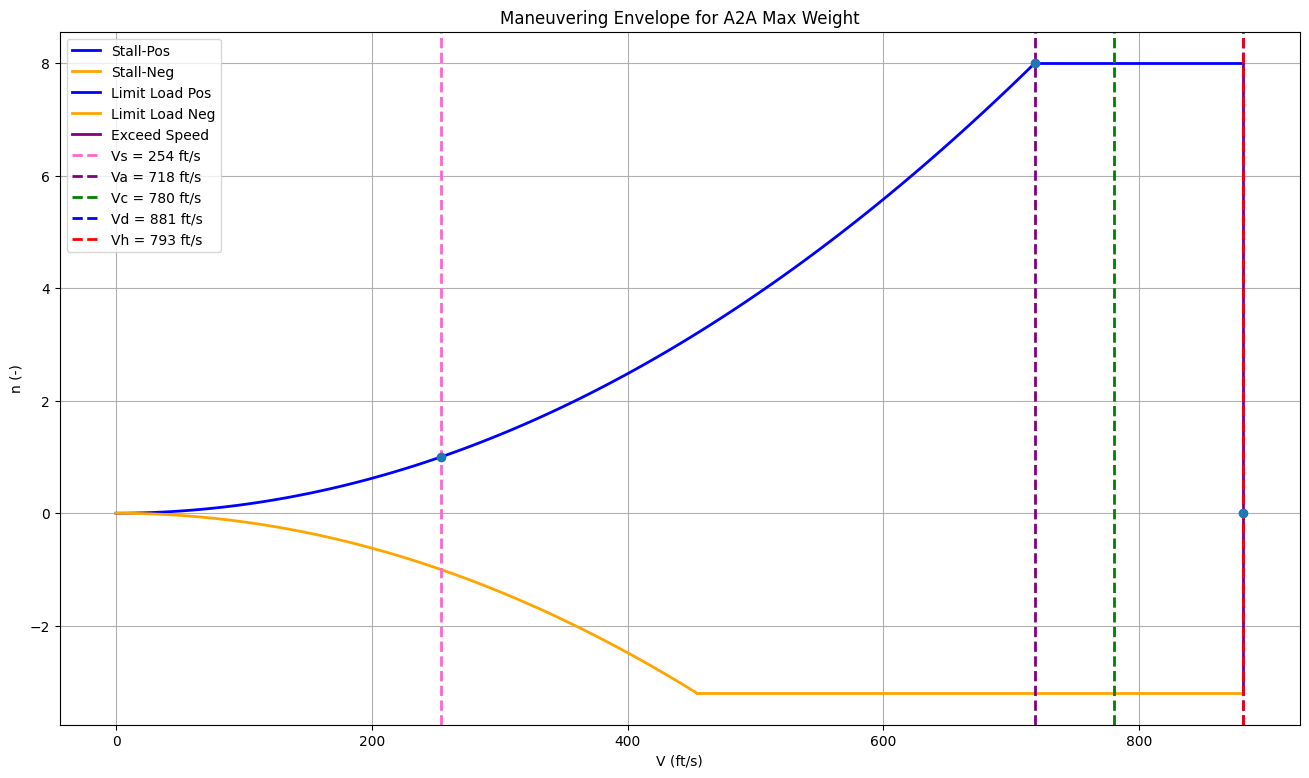

In [22]:
# Plot the exceed speed lines
V_exceed = V_D 

n_exceed_line = np.linspace(n_neg_limit[0], n_pos_limit[0], 100)
V_exceed_line = V_D * np.ones_like(n_exceed_line)


plt.figure(figsize=(16,9))
plt.title('Maneuvering Envelope for A2A Max Weight')
plt.xlabel("V (ft/s)")
plt.ylabel("n (-)")
plt.plot(V_stall_pos, n_stall_pos_intersection  , label='Stall-Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_stall_neg, n_stall_neg_intersection  , label='Stall-Neg', linewidth=2, marker=None, markersize=8, color ='orange')
plt.plot(V_pos_limit_extended, n_pos_extended, label='Limit Load Pos', linewidth=2, marker=None, markersize=8, color = 'blue')
plt.plot(V_neg_limit_extended, n_neg_extended, label='Limit Load Neg', linewidth=2, marker=None, markersize=8, color = 'orange')
plt.plot(V_exceed_line, n_exceed_line,label='Exceed Speed', linewidth=2, color='purple')
# --- Key characteristic speeds ---
plt.axvline(V_s, linestyle='--', color='#ff66cc', linewidth=2, label=f'Vs = {V_s:.0f} ft/s')
plt.axvline(V_A, linestyle='--', color='purple', linewidth=2, label=f'Va = {V_A:.0f} ft/s')
plt.axvline(V_C, linestyle='--', color='green', linewidth=2, label=f'Vc = {V_C:.0f} ft/s')
plt.axvline(V_D, linestyle='--', color='blue', linewidth=2, label=f'Vd = {V_D:.0f} ft/s')
plt.axvline(V_D, linestyle='--', color='red', linewidth=2, label=f'Vh = {V_H:.0f} ft/s')

# Optional markers at n=1 line for clarity
plt.scatter([V_s, V_A, V_D], [1, n_pos_limit[0], 0],
            zorder=5)
plt.grid(True)
plt.legend(loc='best')
plt.show()

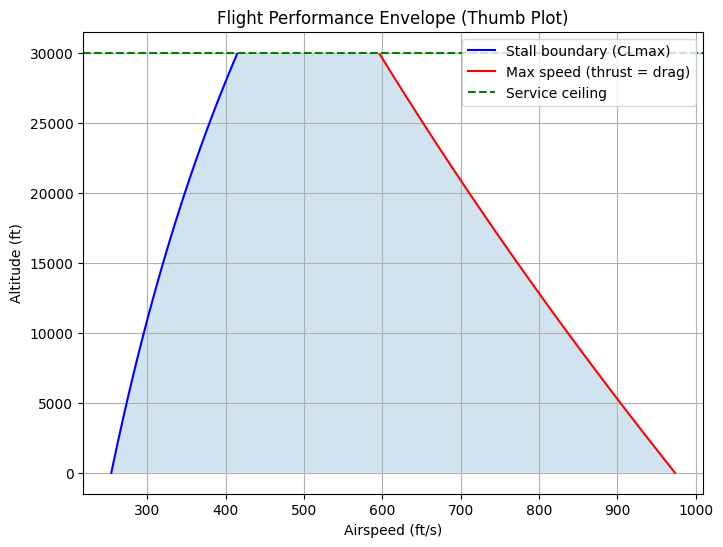

In [ ]:
# FLIGHT ENVELOPE

# Altitude range
alt = np.linspace(0, 40000, 100)  # ft

def density(h):
    return rho_sl * (1 - 6.875e-6 * h)**4.256  # valid up to ~36k ft

# --- Stall boundary ---
# Vs increases with altitude (lower density)
Vs = []
for h in alt:
    rho = density(h)
    Vs.append(np.sqrt(1 / (stall_coeff * (rho / rho_sl))))

Vs = np.array(Vs)

# --- Max speed boundary (simplified) ---
# Assume Vmax decreases slightly with altitude
Vmax = V_max * np.sqrt(density(alt) / rho_sl)

# --- Ceiling (where climb = 0) ---
# define a ceiling altitude
ceiling = 30000  # ft

# mask region above ceiling
valid = alt <= ceiling

# --- Plot ---
plt.figure(figsize=(8,6))

# Stall boundary (left)
plt.plot(Vs[valid], alt[valid], label="Stall boundary (CLmax)", color='blue')

# Max speed boundary (right)
plt.plot(Vmax[valid], alt[valid], label="Max speed (thrust = drag)", color='red')

# Ceiling line
plt.axhline(ceiling, linestyle='--', color='green', label="Service ceiling")

# Fill envelope
plt.fill_betweenx(alt[valid], Vs[valid], Vmax[valid], alpha=0.2)

plt.xlabel("Airspeed (ft/s)")
plt.ylabel("Altitude (ft)")
plt.title("Flight Performance Envelope (Thumb Plot)")
plt.legend()
plt.grid()

plt.show()